# RL Beat Generation — PPO Training (Colab)

Trains a PPO agent to generate drum beats on a 4×16 grid using a hybrid reward:
rule-based musical structure + a pre-trained transformer discriminator.

> **Runtime:** `Runtime → Change runtime type → T4 GPU`

## 1 · Setup

In [1]:
!git clone -b atharv/ppo-discriminator https://github.com/Atharv-Girish-Chaudhary/rl-beat-generation.git
%cd rl-beat-generation
!pip install -e . -q

Cloning into 'rl-beat-generation'...
remote: Enumerating objects: 326, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 326 (delta 26), reused 120 (delta 9), pack-reused 181 (from 1)
Receiving objects: 100% (326/326), 8.32 MiB | 15.61 MiB/s, done.
Resolving deltas: 100% (113/113), done.
/content/rl-beat-generation
  Preparing metadata (setup.py) ... done


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import zipfile
import shutil, os

drive_path = "/content/drive/MyDrive/02_Coding_&_Projects/rl-beat-generation"
zip_path = "/content/drive/MyDrive/02_Coding_&_Projects/rl-beat-generation/samples.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/rl-beat-generation")
print("✅ Samples ready")

✅ Samples ready


## 2 · Imports + Device Check

In [2]:
import sys
import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')  # headless backend; we'll call plt.show() explicitly in Colab
import matplotlib.pyplot as plt

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = "cuda"
    props = torch.cuda.get_device_properties(0)
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {props.total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    device = "mps"
    print("GPU  : Apple MPS")
else:
    device = "cpu"
    print("GPU  : none — running on CPU (training will be slow)")

# ── System RAM ────────────────────────────────────────────────────────────────
try:
    import psutil
    vm = psutil.virtual_memory()
    print(f"RAM  : {vm.total/1e9:.1f} GB total, {vm.available/1e9:.1f} GB available")
except ImportError:
    # psutil not always installed in Colab base image; fall back to /proc
    with open('/proc/meminfo') as f:
        lines = {k.strip(): v.strip() for k, v in
                 (l.split(':', 1) for l in f if ':' in l)}
    total_kb = int(lines.get('MemTotal', '0 kB').split()[0])
    avail_kb = int(lines.get('MemAvailable', '0 kB').split()[0])
    print(f"RAM  : {total_kb/1e6:.1f} GB total, {avail_kb/1e6:.1f} GB available")

print(f"\nPython : {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")

GPU  : NVIDIA H100 80GB HBM3
VRAM : 85.0 GB
RAM  : 247.0 GB total, 243.3 GB available

Python : 3.12.13
PyTorch: 2.10.0+cu128


## 3 · Config

All hyperparameters in one place. Edit here, everything downstream picks them up.

Key change from original training: `ALPHA=0.6 / BETA=0.4` gives the discriminator
more influence (was 0.9 / 0.1), which should push the agent toward more groove-like patterns.

In [ ]:
ALPHA               = 0.6      # rule reward weight
BETA                = 0.4      # discriminator weight  (ALPHA + BETA = 1.0)
EPOCHS              = 250
EPISODES_PER_EPOCH  = 32
LR_ACTOR            = 3e-4
LR_CRITIC           = 1e-3
DISC_PATH           = "outputs/checkpoints/discriminator_phase1_v2.pt"

print("Config:")
print(f"  alpha={ALPHA}, beta={BETA}  (rule vs discriminator weight)")
print(f"  epochs={EPOCHS}, episodes/epoch={EPISODES_PER_EPOCH}")
print(f"  lr_actor={LR_ACTOR}, lr_critic={LR_CRITIC}")
print(f"  disc_path={DISC_PATH}")

## 4 · Discriminator Load + Sanity Check

In [ ]:
import os, shutil
from google.colab import files
uploaded = files.upload()  # select discriminator_phase1_v2.pt
os.makedirs("outputs/checkpoints", exist_ok=True)
shutil.move("discriminator_phase1_v2.pt", "outputs/checkpoints/discriminator_phase1_v2.pt")
print("✅ Checkpoint moved to outputs/checkpoints/discriminator_phase1_v2.pt")

In [ ]:
from beat_rl.models import BeatDiscriminator

L, T = 4, 16

disc = BeatDiscriminator(
    num_instruments=L, num_steps=T,
    d_model=64, num_heads=4, num_blocks=2, d_ff=128
).to(device)
disc.load_state_dict(torch.load(DISC_PATH, map_location=device))
disc.eval()
print(f"Loaded discriminator from {DISC_PATH}")

# ── Forward pass 1: completely silent grid (expect low score) ─────────────────
silent = torch.zeros(1, L, T, device=device)
with torch.no_grad():
    logit, _ = disc(silent)
score_silent = torch.sigmoid(logit).item()

# ── Forward pass 2: structured beat (kick/snare/hihat pattern) ───────────────
structured = torch.zeros(1, L, T)
structured[0, 0, [0, 4, 8, 12]] = 1.0   # kick on quarter notes
structured[0, 1, [4, 12]]       = 1.0   # snare on 2 & 4
structured[0, 2, list(range(0, 16, 2))] = 1.0  # hihat on 8th notes
structured[0, 3, [4, 12]]       = 1.0   # clap with snare
with torch.no_grad():
    logit2, _ = disc(structured.to(device))
score_structured = torch.sigmoid(logit2).item()

print(f"\nOutput shape      : {logit.shape}  (batch=1, logit=1)")
print(f"Silent grid score : {score_silent:.4f}  (expect < 0.5)")
print(f"Structured score  : {score_structured:.4f}  (expect > silent)")

assert score_structured > score_silent, \
    "Discriminator sanity check failed: structured beat should score higher than silence"
print("\nSanity check passed.")

## 5 · Training

Epoch logs stream as they arrive. Each line shows:
`Epoch N | Mean Reward | Actor Loss | Critic Loss`

A checkpoint is saved whenever mean reward improves.
Expected training time: ~2–3 h on T4, ~40 min on A100.

In [6]:
import sys
sys.path.insert(0, '.')
from scripts.train_ppo import train_ppo

history = train_ppo(
    epochs=EPOCHS,
    episodes_per_epoch=EPISODES_PER_EPOCH,
    pi_lr=LR_ACTOR,
    v_lr=LR_CRITIC,
    alpha=ALPHA,
    beta=BETA,
)

--- 🧠 Beat Generation PPO Pipeline ---
Accelerating on Device: cuda
Loading Pre-trained Discriminator...

Commencing PPO Training Loop...
  ✅ New best model saved! (Reward: 0.536)
Epoch 01/250 | Mean Reward: 0.536 | Actor Loss: -0.301 | Critic Loss: 0.005
  ✅ New best model saved! (Reward: 0.552)
Epoch 02/250 | Mean Reward: 0.552 | Actor Loss: -0.293 | Critic Loss: 0.009
  ✅ New best model saved! (Reward: 0.554)
Epoch 03/250 | Mean Reward: 0.554 | Actor Loss: -0.290 | Critic Loss: 0.006
  ✅ New best model saved! (Reward: 0.606)
Epoch 04/250 | Mean Reward: 0.606 | Actor Loss: -0.290 | Critic Loss: 0.005
  ✅ New best model saved! (Reward: 0.637)
Epoch 05/250 | Mean Reward: 0.637 | Actor Loss: -0.287 | Critic Loss: 0.002
  ✅ New best model saved! (Reward: 0.662)
Epoch 06/250 | Mean Reward: 0.662 | Actor Loss: -0.284 | Critic Loss: 0.002
  ✅ New best model saved! (Reward: 0.665)
Epoch 07/250 | Mean Reward: 0.665 | Actor Loss: -0.284 | Critic Loss: 0.002
Epoch 08/250 | Mean Reward: 0.660 | 

In [21]:
shutil.copytree("outputs/checkpoints", f"{drive_path}/checkpoints", dirs_exist_ok=True)
# Plots
shutil.copytree("outputs/plots", f"{drive_path}/plots", dirs_exist_ok=True)
print("✅ Checkpoints and plots saved to Drive")

✅ Checkpoints and plots saved to Drive


## 6 · Loss Curves

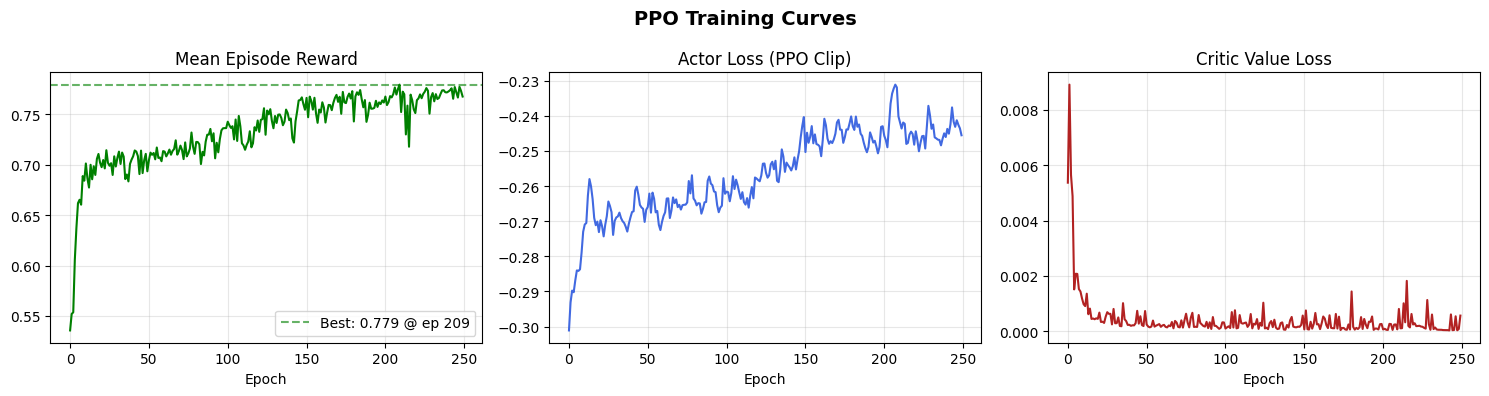

In [22]:
import matplotlib
matplotlib.use('inline')   # switch to inline for Colab display
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Reward
rewards = history['mean_rewards']
best_r  = max(rewards)
best_ep = rewards.index(best_r)
axes[0].plot(rewards, color='green', linewidth=1.5)
axes[0].axhline(best_r, color='green', linestyle='--', alpha=0.6,
                label=f'Best: {best_r:.3f} @ ep {best_ep}')
axes[0].set_title('Mean Episode Reward')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Actor loss
axes[1].plot(history['actor_loss'], color='royalblue', linewidth=1.5)
axes[1].set_title('Actor Loss (PPO Clip)')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

# Critic loss
axes[2].plot(history['critic_loss'], color='firebrick', linewidth=1.5)
axes[2].set_title('Critic Value Loss')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle('PPO Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 · Audio Generation

Loads the best saved actor, runs one inference episode, renders the beat grid to WAV,
and plays it inline.

In [23]:
import soundfile as sf
import numpy as np
from IPython.display import Audio, display

from beat_rl.env.beat_env import BeatGridEnv
from beat_rl.models.actor import CNNLayerStepSampleActor
from scripts.generate_audio import (
    generate_beat, render_grid as render_audio,
    _dummy_reward, LAYER_TO_SAMPLES, L, T, S
)

SR  = 44100
BPM = 120.0
N_BARS = 4

# Load best actor checkpoint
actor = CNNLayerStepSampleActor(
    L=L, T=T, S=S, env_layer_to_samples=LAYER_TO_SAMPLES
).to(device)
actor.load_state_dict(torch.load("outputs/checkpoints/actor_best.pth", map_location=device))
actor.eval()

env = BeatGridEnv(
    L=L, T=T, S=S,
    reward_fn=_dummy_reward,
    layer_to_samples=LAYER_TO_SAMPLES,
    phase=1,
)

# Generate beat grid
grid = generate_beat(actor, env, device=device)

print("Generated grid (rows=layers, cols=16th-note steps):")
for i, name in enumerate(['kick ', 'snare', 'hihat', 'clap ']):
    row = ' '.join(f'{v:2d}' for v in grid[i])
    print(f"  {name}: [{row}]")

# Render to audio
one_bar, bar_samples = render_audio(grid, bpm=BPM, sr=SR)
pure_bar = one_bar[:bar_samples]
looped   = np.concatenate([pure_bar] * (N_BARS - 1) + [one_bar])

out_wav = "outputs/beat_sample.wav"
sf.write(out_wav, looped, SR)
print(f"\nSaved: {out_wav}  ({len(looped)/SR:.2f}s at {BPM} BPM)")

display(Audio(out_wav))

Generated grid (rows=layers, cols=16th-note steps):
  kick : [ 6  4  0  7  1  6 10  7  6 14  1  3  4 12  0  4]
  snare: [14  9  5  1  1 14  5 11 11  4  1 11  5  6  9  4]
  hihat: [12  9 14  0  4  0 13  0  3 12  5  0  4  0  0  0]
  clap : [ 0  0  0  0 13  0  0  0  0  0  0  0  2  0  0  0]

Saved: outputs/beat_sample.wav  (9.00s at 120.0 BPM)


## 8 · Grid Visualization — First vs Best

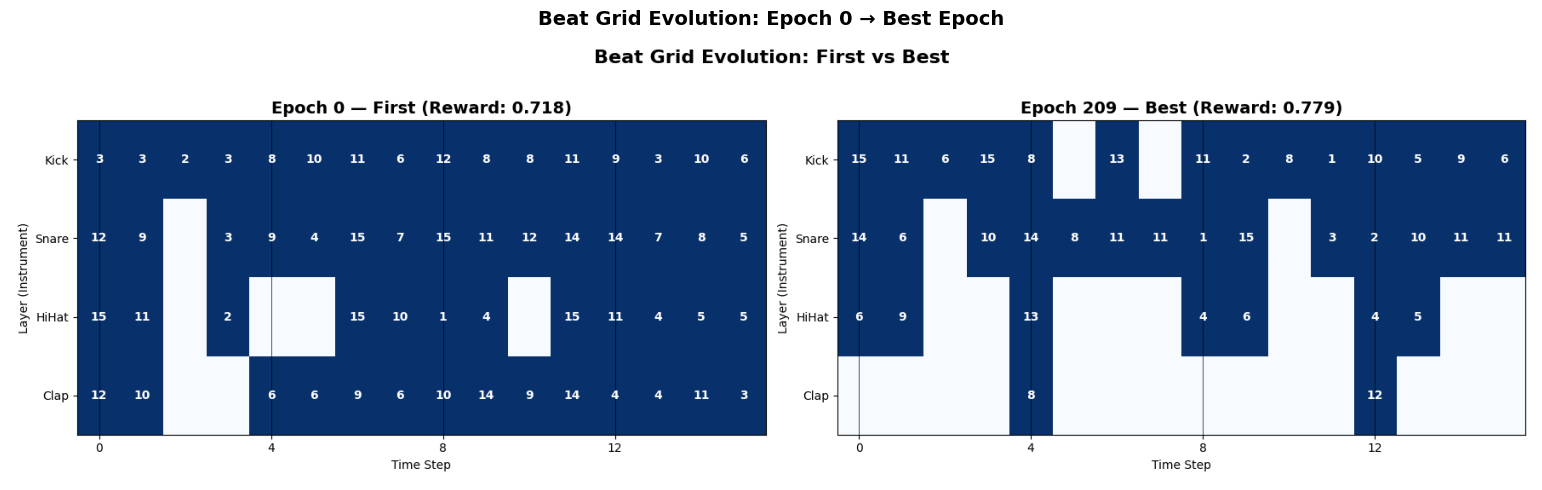

Epoch 0   reward : 0.5357
Best epoch (209) : 0.7794
Improvement      : +0.2438


In [24]:
import glob
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

comparison_path = "outputs/plots/first_vs_best_comparison.png"

# ── Side-by-side comparison saved by train_ppo ───────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.imshow(mpimg.imread(comparison_path))
ax.axis('off')
ax.set_title('Beat Grid Evolution: Epoch 0 → Best Epoch', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# ── Per-epoch reward annotation ───────────────────────────────────────────────
rewards = history['mean_rewards']
best_ep = int(np.argmax(rewards))
print(f"Epoch 0   reward : {rewards[0]:.4f}")
print(f"Best epoch ({best_ep:3d}) : {rewards[best_ep]:.4f}")
print(f"Improvement      : +{rewards[best_ep] - rewards[0]:.4f}")

In [25]:
!python evaluation/evaluate.py --n_episodes 20 --seed 42

Device: cuda
Actor  : /content/rl-beat-generation/outputs/checkpoints/actor_best.pth
Disc   : /content/rl-beat-generation/outputs/checkpoints/discriminator_v1.pt

Running 20 episodes...

  ep   1/20  disc=0.045  rule=0.860  density=0.609  groove=0.359
  ep   2/20  disc=0.045  rule=0.850  density=0.625  groove=0.350
  ep   3/20  disc=0.044  rule=0.860  density=0.672  groove=0.326
  ep   4/20  disc=0.045  rule=0.840  density=0.672  groove=0.279
  ep   5/20  disc=0.045  rule=0.850  density=0.672  groove=0.302
  ep   6/20  disc=0.045  rule=0.850  density=0.672  groove=0.302
  ep   7/20  disc=0.045  rule=0.860  density=0.641  groove=0.317
  ep   8/20  disc=0.044  rule=0.840  density=0.734  groove=0.298
  ep   9/20  disc=0.044  rule=0.860  density=0.672  groove=0.326
  ep  10/20  disc=0.044  rule=0.870  density=0.688  groove=0.318
  ep  11/20  disc=0.045  rule=0.840  density=0.688  groove=0.318
  ep  12/20  disc=0.045  rule=0.850  density=0.656  groove=0.286
  ep  13/20  disc=0.045  rule=0.8

In [26]:
import shutil
shutil.copy("outputs/evaluation_report.json", "/content/drive/MyDrive/02_Coding_&_Projects/rl-beat-generation/evaluation_report.json")
print("✅ Saved")

✅ Saved


In [27]:
git add notebooks/train_ppo_colab.ipynb
git commit -m "add Colab training notebook with debugging and audio generation"
git push origin atharv/ppo-discriminator

SyntaxError: invalid syntax (346905777.py, line 1)